# Optimizing drive and synaptic weight to hit a target firing rate

One recurrently connected population, driven by a current clamp. Two knobs, deliberately of
different kinds:

| dimension | where it ends up | rebuild? |
|---|---|---|
| `clamp.amp_na` | the simulation config JSON | no |
| `conn.syn_weight` | `edge_types.csv`, inside the network files | **yes** |

Target: mean firing rate of the population inside a band.

The two interact — external drive and recurrent excitation both push the rate up — so there is a
whole family of solutions rather than one point. That is exactly the situation CMA-ES handles well
and independent sampling handles badly.

Because `syn_weight` is structural, **every trial rebuilds the network**. Correct, and the cost of
tuning something baked into the SONATA files. The run reports how many rebuilds happened.

In [1]:
import contextlib
import io
import os
import sys

# Prefer this repository's sources over any previously installed copy:
# neuroworkflow.optimization is new and an older install would not have it.
sys.path.insert(0, os.path.abspath('../src'))

from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.network.NW_Population      import NW_Population
from neuroworkflow.nodes.network.NW_Connectivity    import NW_Connectivity
from neuroworkflow.nodes.simulation.NW_SimConfig    import NW_SimConfig
from neuroworkflow.nodes.analysis.NW_Analysis       import NW_Analysis
from neuroworkflow.nodes.stimulus.NW_IClamp         import NW_IClamp

from neuroworkflow.optimization import AlgorithmConfig, build_spec, optimize

## 1. Nodes

In [2]:
clamp = NW_IClamp("clamp")
exc   = NW_Population("exc")
conn  = NW_Connectivity("conn")
sim   = NW_SimConfig("sim")
ana   = NW_Analysis("ana")

## 2. Configure

`I_e = 0`, so the current clamp is the only external drive — otherwise a constant bias current
would do the work and `amp_na` would barely matter. The clamp covers 450 ms of the 500 ms run, so
the measured rate reflects the driven state rather than being diluted by silent time.

The single recurrent projection carries no `syn_weight` of its own, so it inherits the node-level
default — the value the optimizer tunes.

In [3]:
exc.configure(
    pop_name="exc", N=20,
    model_type="point_neuron", model_template="nest:iaf_psc_alpha",
    ei_type="exc", location="VISp", layer="L4",
    nest_params={"C_m": 250.0, "tau_m": 10.0, "t_ref": 2.0,
                 "V_th": -55.0, "V_reset": -70.0, "E_L": -70.0, "I_e": 0.0},
)

clamp.configure(amp_na=200.0, delay_ms=50.0, duration_ms=450.0)

conn.configure(
    connection_rule = 1,                                  # deterministic: one synapse per pair
    syn_weight      = 5.0,                                # node default -> tuned
    connections     = [{"source": "exc", "target": "exc"}],
)

sim.configure(simulator="pointnet", config_file="config_clamp_weight.json",
              tstop_ms=500.0, dt_ms=0.1)
ana.configure(plot_raster=False, plot_traces=False)

## 3. Build

In [4]:
wf = WorkflowBuilder("NW_Clamp_Weight_Optimization")
for node in [clamp, exc, conn, sim, ana]:
    wf.add_node(node)

wf.connect("clamp", "iclamp",     "exc",  "iclamp")
wf.connect("exc",   "population", "conn", "populations")
wf.connect("conn",  "network",    "sim",  "populations")
wf.connect("sim",   "results",    "ana",  "results")

wf.context["results_path"] = "./results/clamp_weight"
workflow = wf.build()
print("nodes:", list(workflow.nodes))

nodes: ['clamp', 'exc', 'conn', 'sim', 'ana']


## 4. Declare what to optimize

Both dimensions are plain scalars, so both ranges are `[min, max]`. The target reads the measured
rate of this population from the analysis node.

In [5]:
explore_clamp_amp_na = clamp.NODE_DEFINITION.parameters["amp_na"]
explore_clamp_amp_na.optimizable        = True
explore_clamp_amp_na.optimization_range = [100.0, 1000.0]
explore_clamp_amp_na.unit               = "nA"

explore_conn_syn_weight = conn.NODE_DEFINITION.parameters["syn_weight"]
explore_conn_syn_weight.optimizable        = True
explore_conn_syn_weight.optimization_range = [1.0, 100.0]
explore_conn_syn_weight.unit               = "pA"

target_exc_mean_firing_rate = exc.NODE_DEFINITION.parameters["mean_firing_rate"]
target_exc_mean_firing_rate.default_value   = 10.0
target_exc_mean_firing_rate.unit            = "Hz"
target_exc_mean_firing_rate.is_objective    = True
target_exc_mean_firing_rate.objective_range = [40.0, 50.0]
target_exc_mean_firing_rate.measures        = (
    f"{ana.name}.firing_rate_hz.{exc._parameters['pop_name']}"
)

print("target measures:", target_exc_mean_firing_rate.measures)

target measures: ana.firing_rate_hz.exc


## 5. Spec

In [6]:
spec = build_spec(
    workflow,
    algorithm=AlgorithmConfig(name="cmaes", pop_size=16, max_generations=12, seed=1),
)

print("baseline measurables:")
for address, value in sorted(spec.baseline["measurables"].items()):
    print(f"   {address:<40} {value:g}")
print()
print(spec.summary())

Executing node: clamp
Executing node: exc
Executing node: conn
Executing node: sim
[NW_SimConfig] network built in ./results/clamp_weight/network

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Mar  4 2025 17:27:39

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-09-07 00:17:42,592 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 00:17:42,600 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-09-07 00:17:42,605 [INFO] Setting up output directory


...

2026-09-07 00:17:42,662 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 00:17:42,681 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
baseline measurables:
   ana.firing_rate_hz.exc                   0
   ana.isi_stats.exc.cv                     0
   ana.isi_stats.exc.mean_ms                0
   ana.isi_stats.exc.n_intervals            0
   ana.isi_stats.exc.std_ms                 0
   clamp.iclamp.amp                         200
   clamp.iclamp.delay                       50
   clamp.iclamp.duration                    450

algorithm : cmaes (pop_size=16, max_generations=12)
dimensions: 2
    clamp.amp_na                             [100.0, 1000.0] nA
    conn.syn_weight                          [1.0, 100.0] pA
objectives: 1
    exc.mean_firing_rate                     in [40.0, 50.0] Hz  <- ana.firing_rate_hz.exc


## 6. Run

Per-trial NEST and BMTK logs are captured so they do not bury the result; the engine's narration is
printed afterwards, with a count of rebuilds.

In [7]:
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    result = optimize(workflow, spec=spec, results_path="./results/clamp_weight/optimization")
captured = buffer.getvalue()

for line in captured.splitlines():
    if line.startswith("[opt_") or line.lstrip().startswith("gen ") or line.startswith("  reusing"):
        print(line)

print(f"\nnetwork rebuilt in {captured.count('network built')} runs, "
      f"reused in {captured.count('network unchanged')}")
print("expected: a rebuild every trial, because syn_weight is structural")

2026-09-07 00:17:43,169 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 00:17:43,173 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-09-07 00:17:43,177 [INFO] Setting up output directory


...

2026-09-07 00:17:55,908 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 00:17:55,930 [INFO] Done.


INFO:NestIOUtils:Done.


[opt_20260907_001743] cmaes: 2 dimensions, 1 objective(s), up to 12 generations x 16 candidates
  reusing network from ./results/clamp_weight
  gen 1, trial 1/16 (#1): clamp.amp_na=475.3 nA  conn.syn_weight=72.31 pA  ->  mean_firing_rate=248 Hz (off 198 Hz)   <- best so far
  gen 1, trial 2/16 (#2): clamp.amp_na=100.1 nA  conn.syn_weight=30.93 pA  ->  mean_firing_rate=0 Hz (off 40 Hz)   <- best so far
  gen 1, trial 3/16 (#3): clamp.amp_na=232.1 nA  conn.syn_weight=10.14 pA  ->  mean_firing_rate=0 Hz (off 40 Hz)
  gen 1, trial 4/16 (#4): clamp.amp_na=267.6 nA  conn.syn_weight=35.21 pA  ->  mean_firing_rate=0 Hz (off 40 Hz)
  gen 1, trial 5/16 (#5): clamp.amp_na=457.1 nA  conn.syn_weight=54.34 pA  ->  mean_firing_rate=212 Hz (off 162 Hz)
  gen 1, trial 6/16 (#6): clamp.amp_na=477.3 nA  conn.syn_weight=68.84 pA  ->  mean_firing_rate=242 Hz (off 192 Hz)
  gen 1, trial 7/16 (#7): clamp.amp_na=284 nA  conn.syn_weight=87.93 pA  ->  mean_firing_rate=0 Hz (off 40 Hz)
  gen 1, trial 8/16 (#8): 

## 7. Result

In [8]:
print("stop reason:", result.stop_reason)
if result.best:
    print("best trial:", result.best["trial"])
    for address, value in result.best["params"].items():
        print(f"  {address:<30} {value:.4g}")
    print("  measured:", result.best["measured"])
    print("  distance from target (raw, per objective):", result.best["fitness"])
    print()
    print(result.configure_snippet())

stop reason: a candidate is inside every target band
best trial: 97
  clamp.amp_na                   430.7
  conn.syn_weight                7.843
  measured: {'exc.mean_firing_rate': 46.0}
  distance from target (raw, per objective): [0.0]

clamp.configure(amp_na=430.6735051488371)
conn.configure(syn_weight=7.8434448541675374)


## 8. How the search evolved

The bottom row is the interesting one here: with two knobs that both raise the rate, expect the
good (dark) points to fall along a trade-off rather than converge on one value of each.

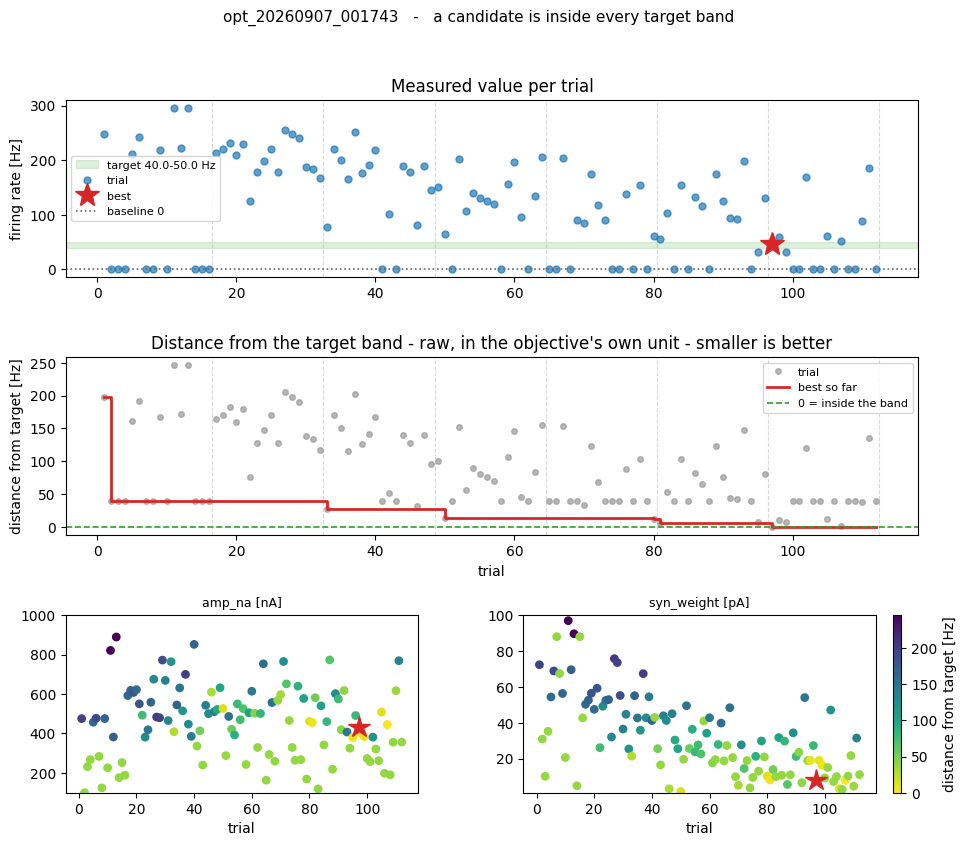

In [9]:
import matplotlib.pyplot as plt

objective = spec.objectives[0]
scored    = [t for t in result.trials if t["fitness"] is not None]

if not scored:
    print("no successful trial to plot")
else:
    x        = [t["trial"] for t in scored]
    measured = [t["measured"][objective.name] for t in scored]
    # One objective, so this is simply how far it missed, in its own unit.
    # With several objectives use t["target_ranges_off"] instead: misses in different
    # units cannot be compared until each is sized against its own target range.
    fitness  = [t["fitness"][0] for t in scored]
    best_so_far, running = [], float("inf")
    for value in fitness:
        running = min(running, value)
        best_so_far.append(running)
    best_trial, pop_size, dims = result.best["trial"], spec.algorithm.pop_size, spec.dimensions

    fig  = plt.figure(figsize=(11, 9))
    grid = fig.add_gridspec(3, max(len(dims), 1), hspace=0.45, wspace=0.3)
    ax_measured = fig.add_subplot(grid[0, :])
    ax_fitness  = fig.add_subplot(grid[1, :])
    dim_axes    = [fig.add_subplot(grid[2, i]) for i in range(len(dims))]

    def generations(ax):
        for boundary in range(pop_size, max(x) + 1, pop_size):
            ax.axvline(boundary + 0.5, color="0.85", lw=0.8, ls="--", zorder=0)

    ax_measured.axhspan(objective.low, objective.high, color="tab:green", alpha=0.15,
                        label=f"target {objective.low}-{objective.high} {objective.unit}")
    generations(ax_measured)
    ax_measured.plot(x, measured, "o", ms=5, color="tab:blue", alpha=0.7, label="trial")
    ax_measured.plot(best_trial, result.best["measured"][objective.name], "*",
                     ms=18, color="tab:red", label="best", zorder=5)
    baseline = spec.baseline.get("measured", {}).get(objective.name)
    if baseline is not None:
        ax_measured.axhline(baseline, color="0.4", ls=":", lw=1.2, label=f"baseline {baseline:.3g}")
    ax_measured.set_ylabel(f"firing rate [{objective.unit}]")
    ax_measured.set_title("Measured value per trial")
    ax_measured.legend(fontsize=8, loc="best")

    generations(ax_fitness)
    ax_fitness.plot(x, fitness, "o", ms=4, color="0.6", alpha=0.7, label="trial")
    ax_fitness.step(x, best_so_far, where="post", color="tab:red", lw=2, label="best so far")
    ax_fitness.axhline(0.0, color="tab:green", lw=1.2, ls="--", label="0 = inside the band")
    ax_fitness.set_xlabel("trial")
    ax_fitness.set_ylabel(f"distance from target [{objective.unit}]"
                          if objective.unit else "distance from target")
    ax_fitness.set_title("Distance from the target band - raw, in the objective's "
                         "own unit - smaller is better")
    ax_fitness.legend(fontsize=8, loc="best")

    points = None
    for ax, dimension in zip(dim_axes, dims):
        values = [t["params"][dimension.address] for t in scored]
        points = ax.scatter(x, values, c=fitness, cmap="viridis_r", s=28)
        ax.plot(best_trial, result.best["params"][dimension.address], "*",
                ms=16, color="tab:red", zorder=5)
        ax.set_ylim(dimension.low, dimension.high)
        ax.set_xlabel("trial")
        ax.set_title(dimension.address.split(".", 1)[1] +
                     (f" [{dimension.unit}]" if dimension.unit else ""), fontsize=9)
    if points is not None:
        fig.colorbar(points, ax=dim_axes, fraction=0.03, pad=0.02,
                     label=f"distance from target [{objective.unit}]"
                           if objective.unit else "distance from target")

    fig.suptitle(f"{result.run_id}   -   {result.stop_reason}", fontsize=11)
    plt.show()

## 9. Adopt the winner

In [10]:
result.apply_best(workflow, execute=True)
print("amp_na      =", clamp._parameters["amp_na"])
print("syn_weight  =", conn._parameters["syn_weight"])
print("firing rate =", ana._output_ports["firing_rate_hz"].value)

Executing node: clamp
Executing node: exc
Executing node: conn
Executing node: sim
[NW_SimConfig] network built in results/clamp_weight/optimization/opt_20260907_001743/trials/0112/network
2026-09-07 00:17:56,150 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 00:17:56,155 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-09-07 00:17:56,160 [INFO] Setting up output directory


...

2026-09-07 00:17:56,220 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 00:17:56,244 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
amp_na      = 430.6735051488371
syn_weight  = 7.8434448541675374
firing rate = {'exc': 46.0}


## Notes

- **Degenerate by design.** Drive and recurrent weight trade off, so many combinations hit the band.
  The optimizer stops at the first one that does — it is not looking for a unique answer.
- **Every trial rebuilt the network**, because `syn_weight` lives in the SONATA edge files. Tuning
  `nest_params` or synapse `dynamics_params_dict` instead would reuse the network throughout.
- **If everything reports 0 Hz**, the clamp is not reaching threshold: raise the `amp_na` range or
  lower `V_th`. If the rate is pinned high, lower both ranges.